In [ ]:
!pip install pytorch-tabnet -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00


In [ ]:
!pip install streamlit scapy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.1 MB/s eta 0:00:00


In [ ]:
!pip install pyngrok

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
def reproducibility_establishment(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set seed
seed_pi = 314159
reproducibility_establishment(seed_pi)

In [ ]:
DATA_PATH = "/content/drive/MyDrive/MachineLearningCVE"

Found CSV files:
/content/drive/MyDrive/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


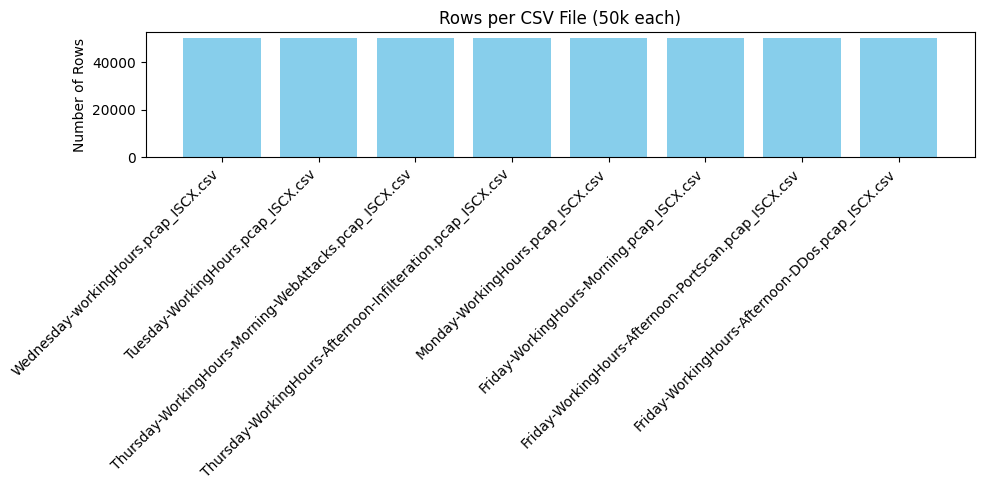

Combined DataFrame shape: (400000, 79)
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'UR

In [ ]:
import glob

csv_files = glob.glob(f"{DATA_PATH}/*.csv")
print("Found CSV files:")
for f in csv_files:
    print(f)

dfs = []
file_names = []
row_counts = []

for file in csv_files:
    df = pd.read_csv(file, nrows=50000)
    dfs.append(df)
    file_name = file.split("/")[-1]
    file_names.append(file_name)
    row_counts.append(df.shape[0])

plt.figure(figsize=(10, 5))
plt.bar(range(len(row_counts)), row_counts, color='skyblue')
plt.xticks(range(len(file_names)), file_names, rotation=45, ha='right')
plt.ylabel("Number of Rows")
plt.title("Rows per CSV File (50k each)")
plt.tight_layout()
plt.show()

df_data = pd.concat(dfs, ignore_index=True)
df_data.columns = df_data.columns.str.strip()

print("Combined DataFrame shape:", df_data.shape)
print("Columns:", df_data.columns.tolist())

label_counts = df_data['Label'].value_counts()

In [ ]:
# binary_label_counts = y_b.value_counts()

# plt.figure(figsize=(8, 5))
# plt.bar(['BENIGN' if x == 0 else 'ATTACK' for x in binary_label_counts.index], binary_label_counts.values, color=['green', 'red'])
# plt.xticks(rotation=0)
# plt.ylabel("Count")
# plt.xlabel("Label")
# plt.title("Binary Class Distribution (Benign vs. Attack)")
# plt.tight_layout()
# plt.show()

In [ ]:
df_data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Check for nulls
print("Total null values:", df_data.isnull().sum().sum())

# Drop nulls if any
df_data = df_data.dropna()

# Check for duplicates
print("Duplicate rows:", df_data.duplicated().sum())

# Drop duplicates
df_data = df_data.drop_duplicates().reset_index(drop=True)

print("Data shape after cleaning:", df_data.shape)

Total null values: 71
Duplicate rows: 13835
Data shape after cleaning: (386094, 79)


In [ ]:
X = df_data.drop('Label', axis=1)
y = df_data['Label']

Binary target counts:
 Label
0    354337
1     31757
Name: count, dtype: int64


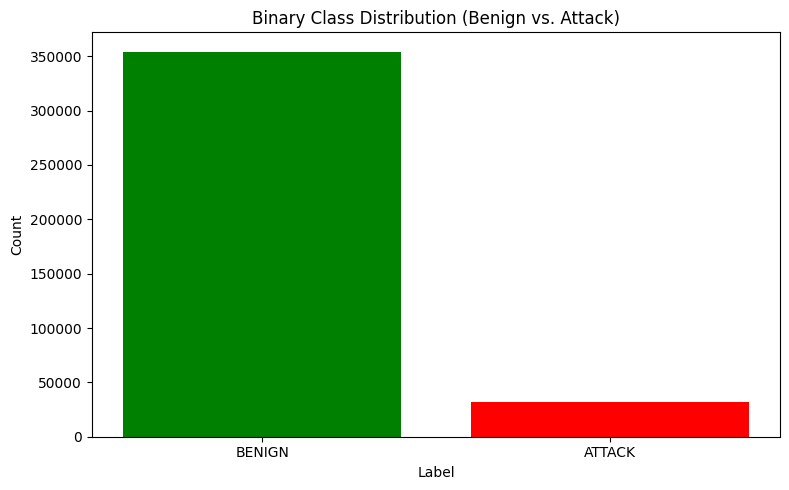

In [ ]:
y_b = y.map(lambda x: 0 if x == "BENIGN" else 1).astype(int)
print("Binary target counts:\n", y_b.value_counts())

binary_label_counts = y_b.value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['BENIGN' if x == 0 else 'ATTACK' for x in binary_label_counts.index], binary_label_counts.values, color=['green', 'red'])
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.xlabel("Label")
plt.title("Binary Class Distribution (Benign vs. Attack)")
plt.tight_layout()
plt.show()

In [ ]:
def extractAllSets(X, y, p_train, p_val, p_test, random_state, shuffle=True):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, stratify=y, test_size=(1.0 - p_train),
        random_state=random_state, shuffle=shuffle
    )
    fraction = p_test / (p_val + p_test)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, stratify=y_temp,
        test_size=fraction, random_state=random_state, shuffle=shuffle
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
# Binary dataset split
X_train_b, X_val_b, X_test_b, y_train_b, y_val_b, y_test_b = extractAllSets(
    X, y_b, 0.75, 0.10, 0.15, seed_pi
)

print("Binary classes in y_train:", np.unique(y_train_b))
print("Binary classes in y_val:", np.unique(y_val_b))

Binary classes in y_train: [0 1]
Binary classes in y_val: [0 1]


In [ ]:
# Quantile Transformation
def q_transformation(data):
    qt = QuantileTransformer(n_quantiles=1000, output_distribution='uniform')
    data_0_tr = qt.fit_transform(data[0])
    data_1_tr = qt.transform(data[1])
    data_2_tr = qt.transform(data[2])
    return [data_0_tr, data_1_tr, data_2_tr]

In [ ]:
# Handle infinite values
X_train_b_processed = X_train_b.copy()
X_val_b_processed = X_val_b.copy()
X_test_b_processed = X_test_b.copy()

for df_proc in [X_train_b_processed, X_val_b_processed, X_test_b_processed]:
    for col in ['Flow Bytes/s', 'Flow Packets/s']:
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].replace([np.inf, -np.inf], np.nan).fillna(0)

In [ ]:
# Apply Quantile Transformation
qt = QuantileTransformer(n_quantiles=1000, output_distribution='uniform')
X_train_b = qt.fit_transform(X_train_b_processed)
X_val_b = qt.transform(X_val_b_processed)
X_test_b = qt.transform(X_test_b_processed)

In [ ]:
# Extract number of features
input_features_0 = X.shape[1]

gamma_fe_0 = 1.85
adam = torch.optim.Adam
scheduler_ElR = torch.optim.lr_scheduler.ExponentialLR
scheduler_params_ElR_loss = {'gamma': 0.9}

# TabNet parameters
clf_0_params = dict(
    n_d=input_features_0,
    n_a=input_features_0,
    n_steps=5,
    n_shared=2,
    n_independent=2,
    momentum=0.02,
    lambda_sparse=0.001,
    clip_value=4.5,
    gamma=gamma_fe_0,
    optimizer_fn=adam,
    optimizer_params=dict(lr=1e-2),
    verbose=5,
    seed=seed_pi,
    device_name=device,
    mask_type="sparsemax",
    scheduler_params=scheduler_params_ElR_loss,
    scheduler_fn=scheduler_ElR
)

clf_0_b = TabNetClassifier(**clf_0_params)

# Training parameters
fit_params_0_b = dict(
    X_train=X_train_b,
    y_train=y_train_b.values,
    eval_set=[(X_val_b, y_val_b.values)],
    patience=80,
    max_epochs=200,
    eval_metric=["logloss", "accuracy"],
    eval_name=["Validation"],
    compute_importance=True,
    batch_size=16384,
    virtual_batch_size=1024,
    num_workers=2,
    drop_last=False,
    pin_memory=True,
    warm_start=False
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [ ]:
print("Training Binary Classifier...")
clf_0_b.fit(**fit_params_0_b)

Training Binary Classifier...
epoch 0  | loss: 0.34621 | Validation_logloss: 0.32459 | Validation_accuracy: 0.91774 |  0:00:05s
epoch 5  | loss: 0.02489 | Validation_logloss: 0.35726 | Validation_accuracy: 0.91756 |  0:00:27s
epoch 10 | loss: 0.01521 | Validation_logloss: 0.15089 | Validation_accuracy: 0.93603 |  0:00:48s
epoch 15 | loss: 0.0127  | Validation_logloss: 0.03263 | Validation_accuracy: 0.9898  |  0:01:10s
epoch 20 | loss: 0.01056 | Validation_logloss: 0.01345 | Validation_accuracy: 0.99565 |  0:01:31s
epoch 25 | loss: 0.00976 | Validation_logloss: 0.01105 | Validation_accuracy: 0.99627 |  0:01:54s
epoch 30 | loss: 0.00927 | Validation_logloss: 0.00891 | Validation_accuracy: 0.99637 |  0:02:16s
epoch 35 | loss: 0.00908 | Validation_logloss: 0.00876 | Validation_accuracy: 0.99637 |  0:02:41s
epoch 40 | loss: 0.00895 | Validation_logloss: 0.00849 | Validation_accuracy: 0.99676 |  0:03:06s
epoch 45 | loss: 0.00868 | Validation_logloss: 0.0084  | Validation_accuracy: 0.99681 | 

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
preds = clf_0_b.predict(X_test_b)

accuracy = accuracy_score(y_test_b, preds)
precision = precision_score(y_test_b, preds)
recall = recall_score(y_test_b, preds)
f1 = f1_score(y_test_b, preds)

print("Binary Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Binary Results
Accuracy: 0.9968747302080635
Precision: 0.9943892965041001
Recall: 0.9674574847785009
F1: 0.9807385335745451


In [ ]:
print("\nTraining Random Forest Baseline...")

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=seed_pi
)

rf_model.fit(X_train_b_processed, y_train_b)
rf_preds = rf_model.predict(X_test_b_processed)

rf_accuracy = accuracy_score(y_test_b, rf_preds)
rf_precision = precision_score(y_test_b, rf_preds)
rf_recall = recall_score(y_test_b, rf_preds)
rf_f1 = f1_score(y_test_b, rf_preds)

print("\nRandom Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)


Training Random Forest Baseline...

Random Forest Results
Accuracy: 0.9930587930587931
Precision: 0.99977079990832
Recall: 0.9158093638463154
F1: 0.9559500328731098


In [ ]:
print("\nCreating Hybrid Model (RF + TabNet)...")

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test_b_processed)

# TabNet probabilities
tabnet_probs = clf_0_b.predict_proba(X_test_b)

# weights (favor TabNet)
rf_weight = 0.2
tabnet_weight = 0.8

# weighted probabilities
hybrid_probs = (rf_weight * rf_probs) + (tabnet_weight * tabnet_probs)

# final prediction
hybrid_preds = np.argmax(hybrid_probs, axis=1)

hybrid_accuracy = accuracy_score(y_test_b, hybrid_preds)
hybrid_precision = precision_score(y_test_b, hybrid_preds)
hybrid_recall = recall_score(y_test_b, hybrid_preds)
hybrid_f1 = f1_score(y_test_b, hybrid_preds)

print("\nHybrid Model Results")
print("Accuracy:", hybrid_accuracy)
print("Precision:", hybrid_precision)
print("Recall:", hybrid_recall)
print("F1:", hybrid_f1)


Creating Hybrid Model (RF + TabNet)...

Hybrid Model Results
Accuracy: 0.9964603297936632
Precision: 0.9962979094076655
Recall: 0.9605290783119882
F1: 0.9780865847140566


In [ ]:
# Calculate improvements
accuracy_improvement = ((hybrid_accuracy - rf_accuracy) / rf_accuracy) * 100
precision_improvement = ((hybrid_precision - rf_precision) / rf_precision) * 100
recall_improvement = ((hybrid_recall - rf_recall) / rf_recall) * 100
f1_improvement = ((hybrid_f1 - rf_f1) / rf_f1) * 100

print(f"Accuracy Improvement: {accuracy_improvement:.2f}%")
print(f"Precision Improvement: {precision_improvement:.2f}%")
print(f"Recall Improvement: {recall_improvement:.2f}%")
print(f"F1 Score Improvement: {f1_improvement:.2f}%")

Accuracy Improvement: 0.34%
Precision Improvement: -0.35%
Recall Improvement: 4.88%
F1 Score Improvement: 2.32%


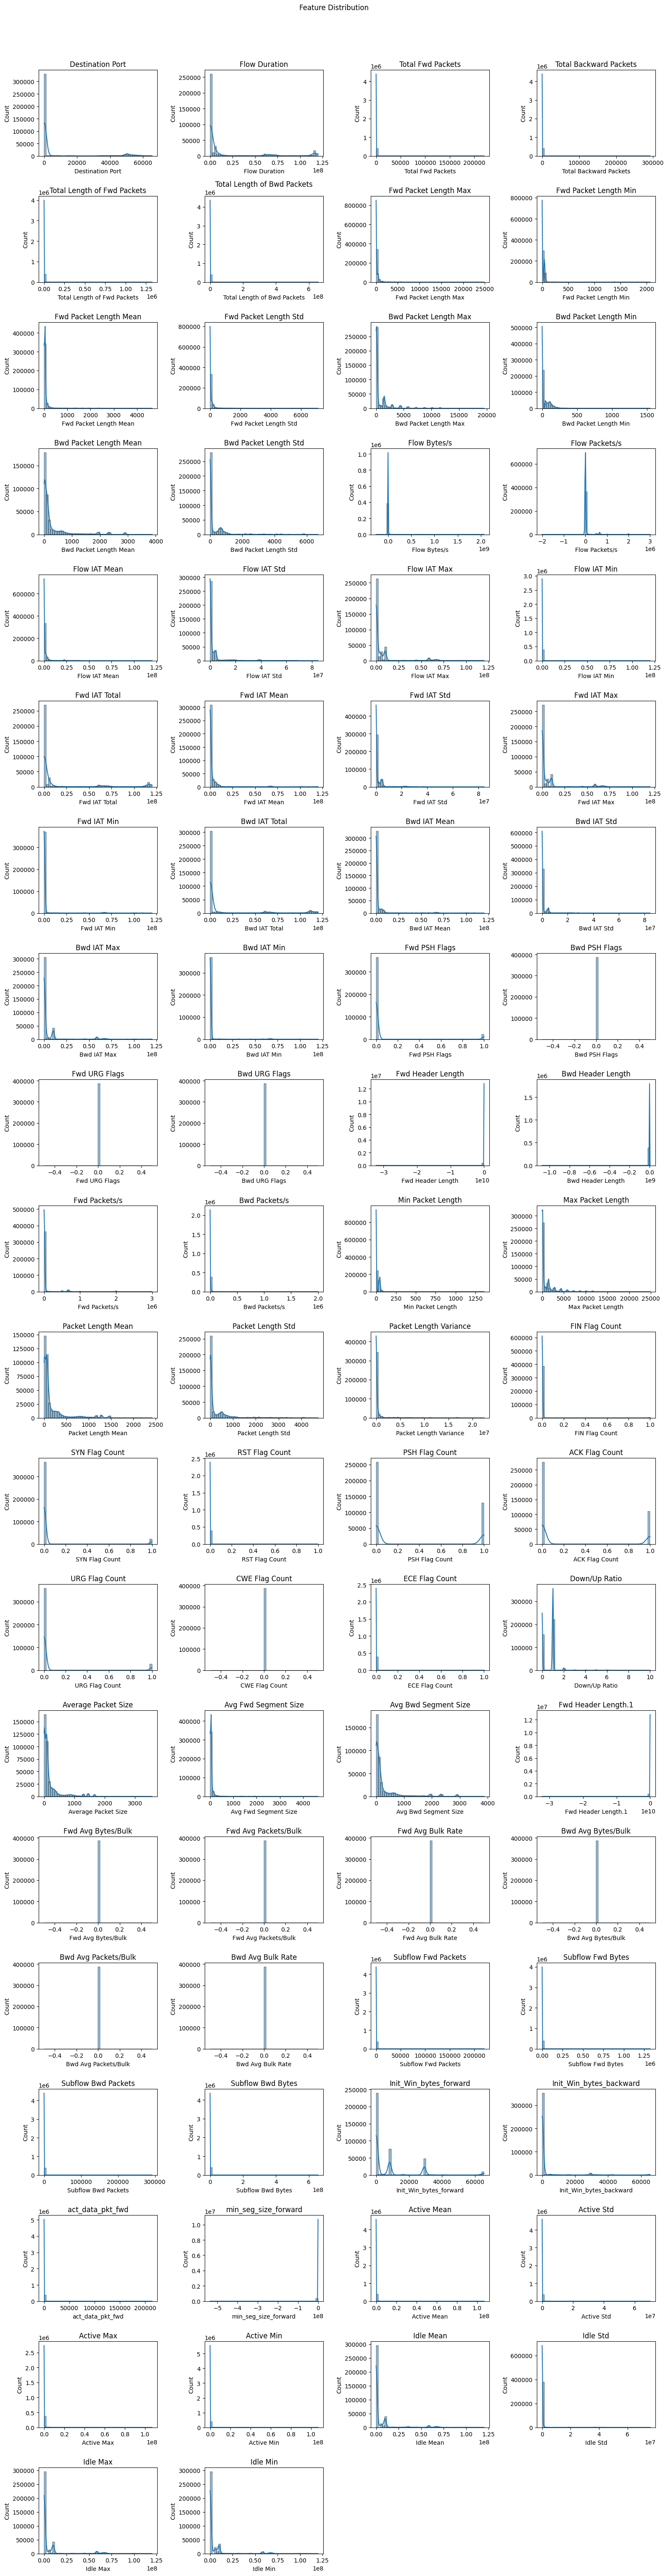

In [ ]:
import math

num_features = df_data.select_dtypes(include=np.number).columns  # all numerical features

# Calculate number of rows and columns dynamically
num_plots = len(num_features)
num_cols = 4  # You can adjust this number
num_rows = math.ceil(num_plots / num_cols)

plt.figure(figsize=(num_cols * 4, num_rows * 3)) # Adjust figure size dynamically

for i, col in enumerate(num_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df_data[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.suptitle("Feature Distribution", y=1.02)
plt.show()

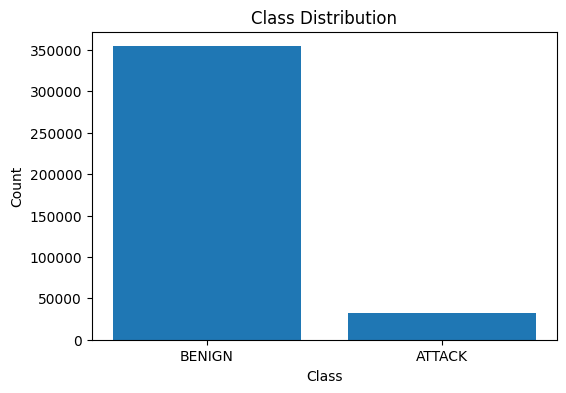

In [ ]:
class_counts = y_b.value_counts()

plt.figure(figsize=(6,4))
plt.bar(['BENIGN','ATTACK'], class_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

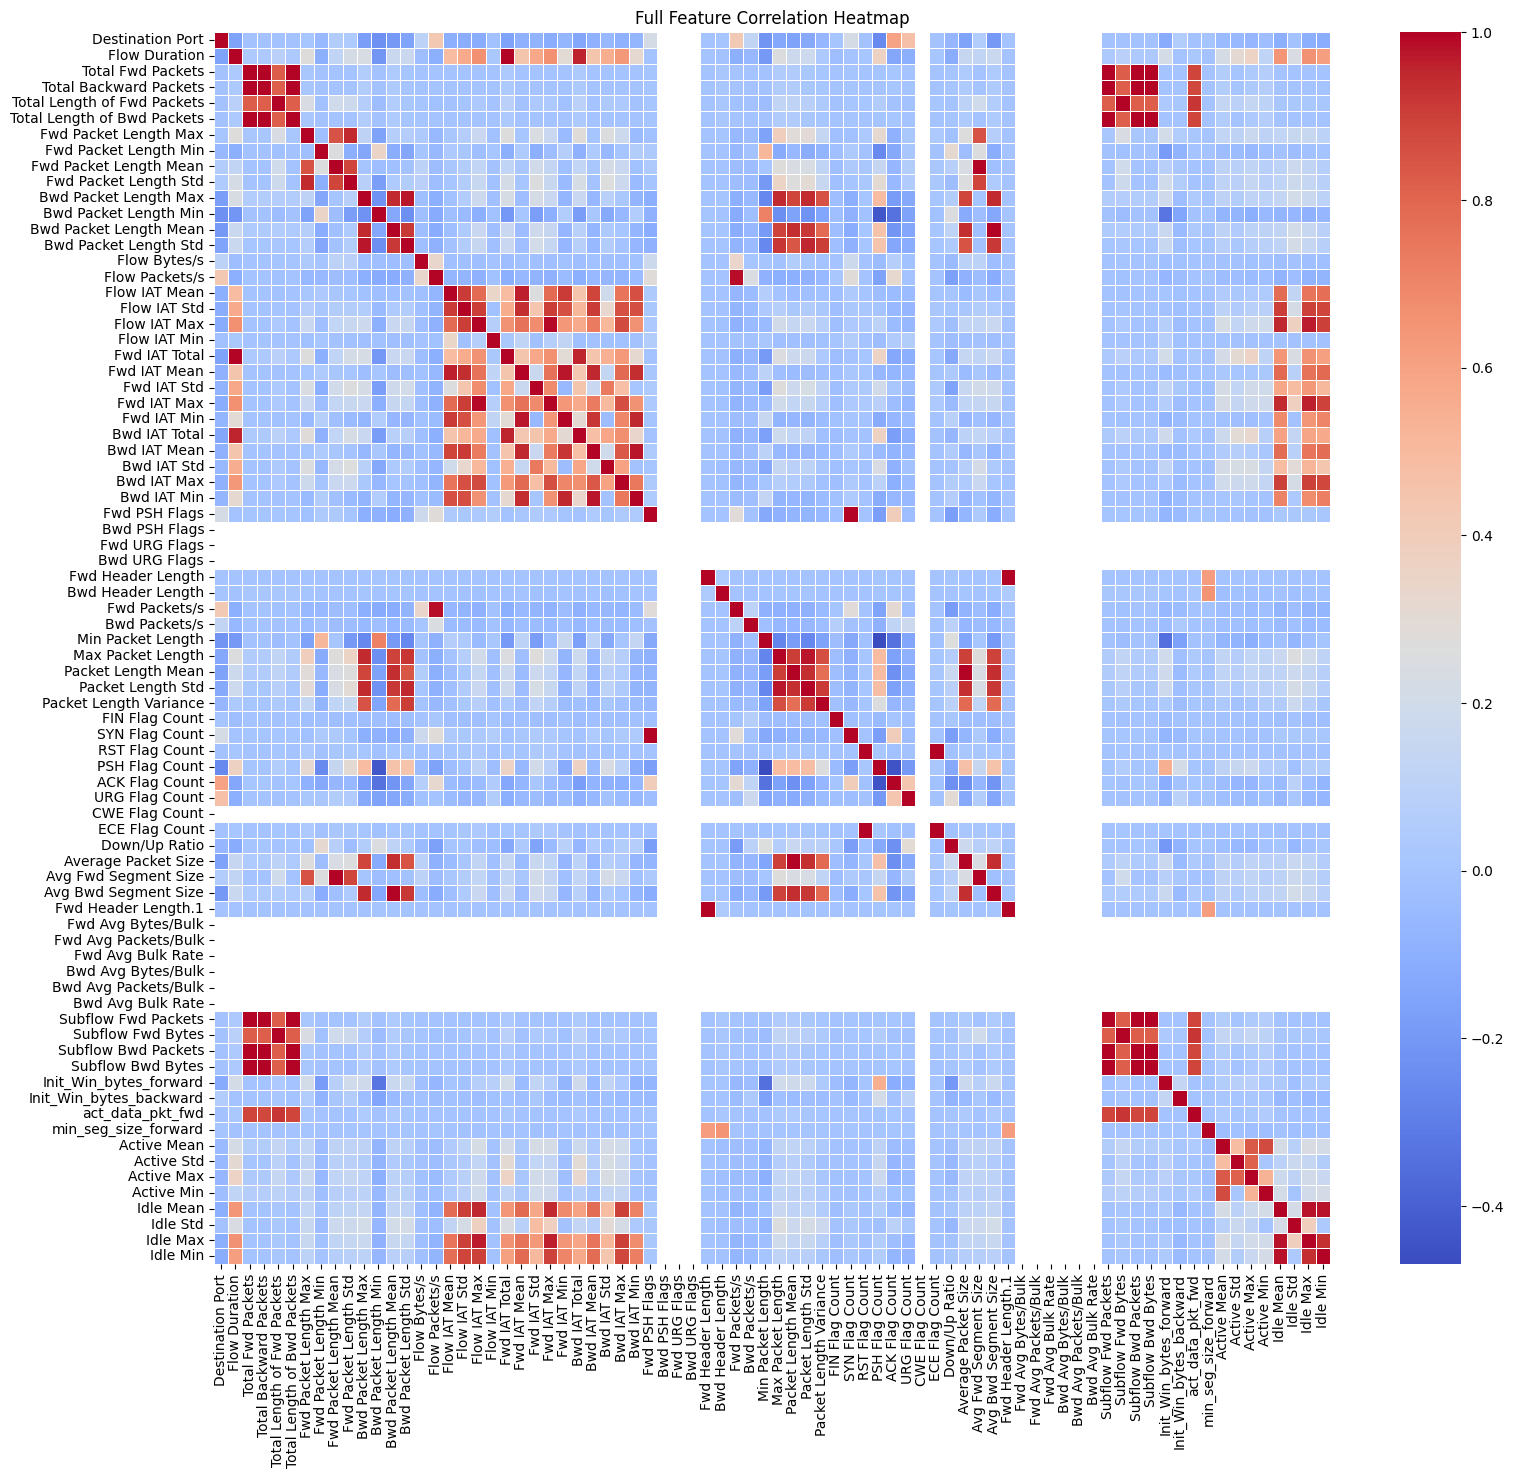

In [ ]:
# Select only numeric columns for correlation calculation
numeric_df = df_data.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Plotting the heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Full Feature Correlation Heatmap')
plt.show()

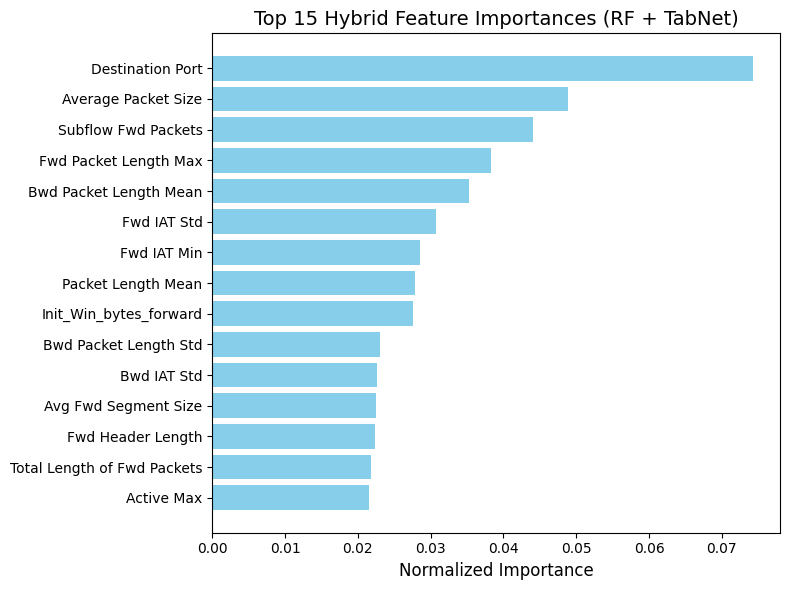

In [ ]:
# Get importances
rf_imp = rf_model.feature_importances_
tabnet_imp = clf_0_b.feature_importances_

# Normalize
rf_norm = rf_imp / np.sum(rf_imp)
tabnet_norm = tabnet_imp / np.sum(tabnet_imp)

# Hybrid (weighted towards TabNet, e.g., 30% RF, 70% TabNet)
hybrid_norm = 0.3 * rf_norm + 0.7 * tabnet_norm

# Create DataFrame
df_hybrid = pd.DataFrame({
    'Feature': X.columns,
    'Hybrid': hybrid_norm
})

# Select top 15 features
df_top = df_hybrid.sort_values('Hybrid', ascending=False).head(15)
df_top = df_top.set_index('Feature')

# Plot horizontal bar chart
plt.figure(figsize=(8,6))
plt.barh(df_top.index, df_top['Hybrid'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Hybrid Feature Importances (RF + TabNet)', fontsize=14)
plt.xlabel('Normalized Importance', fontsize=12)
plt.tight_layout()
plt.show()

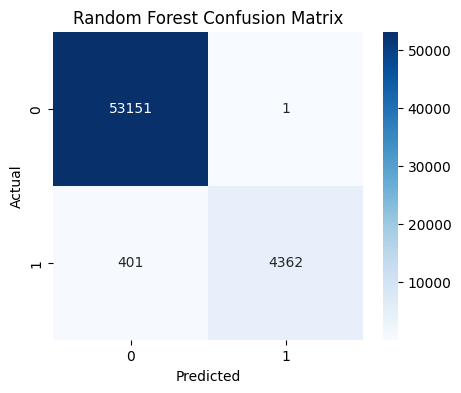

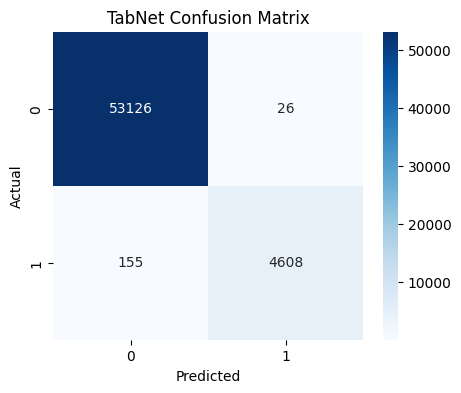

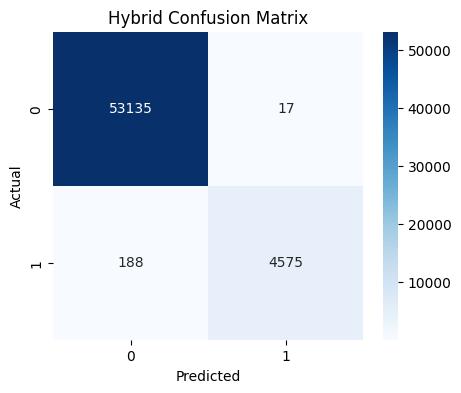

In [ ]:
from sklearn.metrics import confusion_matrix

rf_preds = rf_model.predict(X_test_b_processed)
tabnet_preds = clf_0_b.predict(X_test_b)

models = {
    "Random Forest": rf_preds,
    "TabNet": tabnet_preds,
    "Hybrid": hybrid_preds
}

for name, preds in models.items():

    cm = confusion_matrix(y_test_b, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

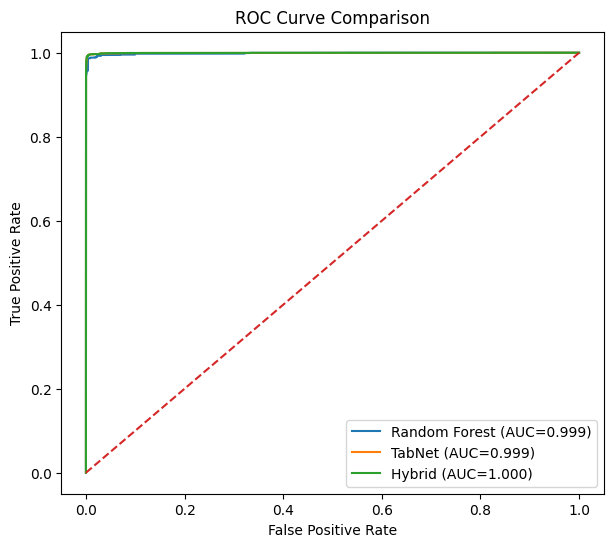

In [ ]:
from sklearn.metrics import roc_curve, auc

rf_probs = rf_model.predict_proba(X_test_b_processed)[:,1]
tabnet_probs = clf_0_b.predict_proba(X_test_b)[:,1]
hybrid_probs = hybrid_probs[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test_b, rf_probs)
tab_fpr, tab_tpr, _ = roc_curve(y_test_b, tabnet_probs)
hyb_fpr, hyb_tpr, _ = roc_curve(y_test_b, hybrid_probs)

rf_auc = auc(rf_fpr, rf_tpr)
tab_auc = auc(tab_fpr, tab_tpr)
hyb_auc = auc(hyb_fpr, hyb_tpr)

plt.figure(figsize=(7,6))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_auc:.3f})")
plt.plot(tab_fpr, tab_tpr, label=f"TabNet (AUC={tab_auc:.3f})")
plt.plot(hyb_fpr, hyb_tpr, label=f"Hybrid (AUC={hyb_auc:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

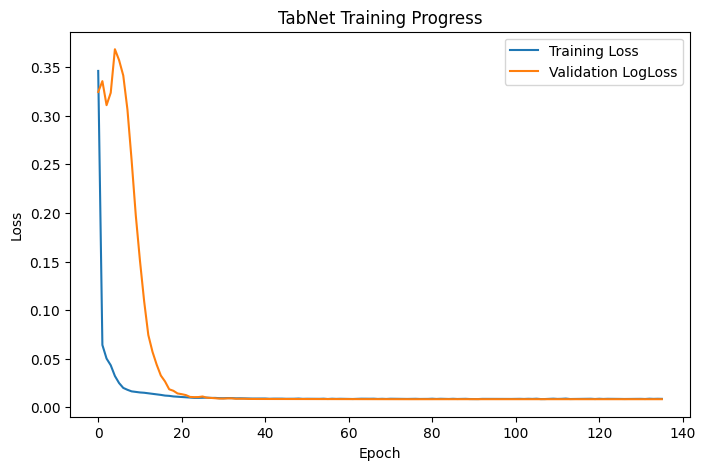

In [ ]:
history = clf_0_b.history

plt.figure(figsize=(8,5))

plt.plot(history['loss'], label='Training Loss')
plt.plot(history['Validation_logloss'], label='Validation LogLoss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TabNet Training Progress")
plt.legend()
plt.show()

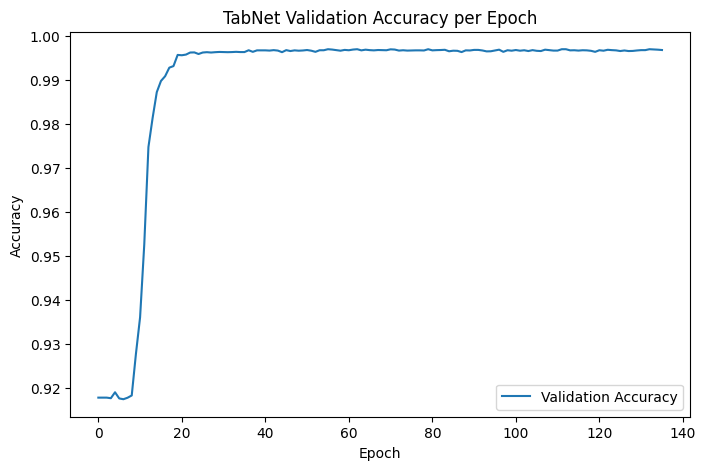

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history['Validation_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TabNet Validation Accuracy per Epoch")
plt.legend()
plt.show()

In [ ]:
import joblib
import json

# --- Save Random Forest ---
joblib.dump(rf_model, "/content/drive/MyDrive/MachineLearningCVE/rf_model.pkl")

# --- Save TabNet ---
clf_0_b.device_name = "cpu"  # temporarily switch to CPU to avoid JSON errors
tabnet_path = "/content/drive/MyDrive/MachineLearningCVE/tabnet_model.zip"
clf_0_b.save_model(tabnet_path)
clf_0_b.device_name = device.type  # restore GPU if needed

# --- Save Hybrid weights ---
hybrid_config = {
    "rf_weight": 0.2,
    "tabnet_weight": 0.8
}
with open("/content/drive/MyDrive/MachineLearningCVE/hybrid_config.json", "w") as f:
    json.dump(hybrid_config, f)

# --- Save Quantile Transformer used during training ---
joblib.dump(qt, "/content/drive/MyDrive/MachineLearningCVE/quantile_transformer.pkl")

Successfully saved model at /content/drive/MyDrive/MachineLearningCVE/tabnet_model.zip.zip


['/content/drive/MyDrive/MachineLearningCVE/quantile_transformer.pkl']